<a href="https://colab.research.google.com/github/YenugulaRamya/my-colab-projects/blob/main/aer_noise_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
get_ipython().system('pip install qiskit qiskit-aer')
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, amplitude_damping_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00


In [ ]:
print(f"Qiskit version: {qiskit.__version__}")
print("Aer noise modules imported successfully")

Qiskit version: 2.3.1
Aer noise modules imported successfully


In [ ]:
single_qubit_circuit= QuantumCircuit(1,1)
single_qubit_circuit.h(0)
single_qubit_circuit.measure(0,0)
bell_measurement_circuit=QuantumCircuit(2,2)
bell_measurement_circuit.h(0)
bell_measurement_circuit.cx(0,1)
bell_measurement_circuit.barrier(label='Measure Bell basis outcomes')
bell_measurement_circuit.measure([0,1],[0,1])
print("Single-qubit reference circuit:")
print(single_qubit_circuit.draw(output='text'))
print("\n Bell-state measurement circuit:")
print(bell_measurement_circuit.draw(output='text'))

Single-qubit reference circuit:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

 Bell-state measurement circuit:
     ┌───┐      Measure Bell basis outcomes ┌─┐   
q_0: ┤ H ├──■────────────────░──────────────┤M├───
     └───┘┌─┴─┐              ░              └╥┘┌─┐
q_1: ─────┤ X ├──────────────░───────────────╫─┤M├
          └───┘              ░               ║ └╥┘
c: 2/════════════════════════════════════════╩══╩═
                                             0  1 


In [ ]:
#from qiskit.providers.aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error, ReadoutError

# Create noise model
noise_model = NoiseModel()

# Define errors
single_qubit_depolarizing = depolarizing_error(param=0.01, num_qubits=1)
two_qubit_depolarizing = depolarizing_error(param=0.03, num_qubits=2)
amplitude_damping = amplitude_damping_error(param_amp=0.02)

# Add quantum errors
noise_model.add_all_qubit_quantum_error(single_qubit_depolarizing, ['h', 'x', 'sx'])
noise_model.add_all_qubit_quantum_error(amplitude_damping, ['h', 'x', 'sx'])
noise_model.add_all_qubit_quantum_error(two_qubit_depolarizing, ['cx'])

# Readout error
readout_matrix = [[0.97, 0.03],
                  [0.04, 0.96]]

readout_error = ReadoutError(readout_matrix)
noise_model.add_all_qubit_readout_error(readout_error)

# Print model
print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 'sx', 'x']
  Instructions with noise: ['measure', 'x', 'cx', 'sx', 'h']
  All-qubits errors: ['h', 'x', 'sx', 'cx', 'measure']


In [ ]:
from qiskit import transpile
from qiskit_aer import AerSimulator

def run_counts(circuit, shots: int, noisy: bool) -> dict:
    """Run circuit on Aer with or without noise and return counts."""
    backend = AerSimulator(noise_model=noise_model) if noisy else AerSimulator()
    transpiled = transpile(circuit, backend)
    result = backend.run(transpiled, shots=shots).result()
    return result.get_counts(transpiled)

shots = 10000

ideal_single_counts = run_counts(single_qubit_circuit, shots=shots, noisy=False)
noisy_single_counts = run_counts(single_qubit_circuit, shots=shots, noisy=True)

ideal_bell_counts = run_counts(bell_measurement_circuit, shots=shots, noisy=False)
noisy_bell_counts = run_counts(bell_measurement_circuit, shots=shots, noisy=True)

print("Single-qubit ideal counts:", ideal_single_counts)
print("Single-qubit noisy counts:", noisy_single_counts)

print("\nBell ideal counts:", ideal_bell_counts)
print("Bell noisy counts:", noisy_bell_counts)

Single-qubit ideal counts: {'0': 5001, '1': 4999}
Single-qubit noisy counts: {'0': 5152, '1': 4848}

Bell ideal counts: {'11': 4964, '00': 5036}
Bell noisy counts: {'01': 419, '11': 4415, '10': 416, '00': 4750}


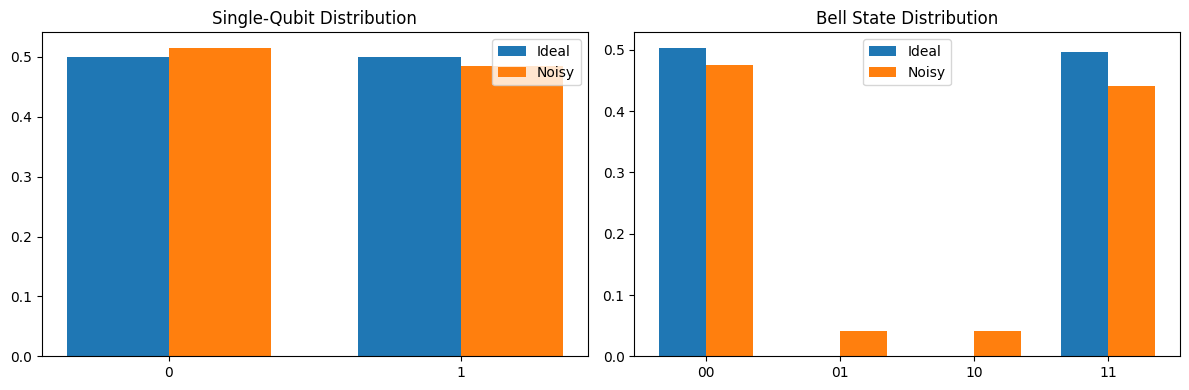

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def normalized_distribution(counts: dict, ordered_bitstrings: list, shots: int) -> list:
    """Convert counts to a probability list in a fixed bitstring order."""
    return [counts.get(bitstring, 0) / shots for bitstring in ordered_bitstrings]

single_labels = ['0', '1']
bell_labels = ['00', '01', '10', '11']

ideal_single_probs = normalized_distribution(ideal_single_counts, single_labels, shots)
noisy_single_probs = normalized_distribution(noisy_single_counts, single_labels, shots)

ideal_bell_probs = normalized_distribution(ideal_bell_counts, bell_labels, shots)
noisy_bell_probs = normalized_distribution(noisy_bell_counts, bell_labels, shots)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_width = 0.35

# Single-qubit plot
x_single = np.arange(len(single_labels))
axes[0].bar(x_single - bar_width / 2, ideal_single_probs, width=bar_width, label='Ideal')
axes[0].bar(x_single + bar_width / 2, noisy_single_probs, width=bar_width, label='Noisy')
axes[0].set_xticks(x_single)
axes[0].set_xticklabels(single_labels)
axes[0].set_title("Single-Qubit Distribution")
axes[0].legend()

# Bell state plot
x_bell = np.arange(len(bell_labels))
axes[1].bar(x_bell - bar_width / 2, ideal_bell_probs, width=bar_width, label='Ideal')
axes[1].bar(x_bell + bar_width / 2, noisy_bell_probs, width=bar_width, label='Noisy')
axes[1].set_xticks(x_bell)
axes[1].set_xticklabels(bell_labels)
axes[1].set_title("Bell State Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()